# Simulating, fitting, subtracting and/or inpainting a sky of clusters

A minimal end-to-end tour of functionality for simulating a sky of Sunyaev-Zel'dovich
clusters and point sources (catalog mode: beam-convolved Arnaud pressure templates from
each cluster's mass and redshift) and later *fitting and subtracting* them from
an observed map (fit mode: per-object GLS amplitudes against the pixel
covariance, built by `soma.maps.fit_object_amplitudes`), returning the
painted model map and mean stacks before and after in the same call. We also
demonstrate how you can inpaint these objects if you don't think they can
be fit well.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pixell import curvedsky, enmap, utils

from soma import maps

# fixed categorical order, validated for colour-vision deficiency
C = ["#2a78d6", "#1baf7a", "#eda100", "#008300"]
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "font.size": 9,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
        "lines.linewidth": 2.0,
    }
)

## 1. Simulate

Draw a cluster catalogue (masses and redshifts) and a point-source
catalogue (peak amplitudes), and let `build_object_model` in **catalog mode**
paint the truth model map: each cluster is a beam-convolved Arnaud (GNFW)
decrement predicted from its (M500c, z) at 150 GHz, each source is the
beam itself.  Add a toy CMB realization (beam-convolved) and white noise
to form the observed map.

soma.szmodel: {'clusters': 60, 'sources': 20} objects on 1 rank(s); amp_mode=catalog, stacks=False


soma.szmodel: painting 80 object models (skipped 0, gated 0)


soma.szmodel: done in 0.7s


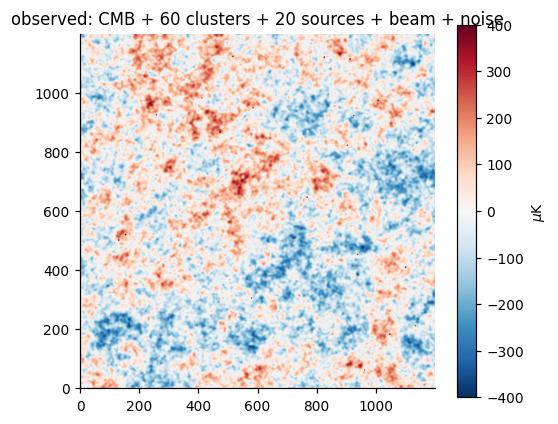

In [2]:
rng = np.random.default_rng(0)
PIX, BEAM_FWHM, NOISE, FREQ = 0.5, 1.4, 10.0, 150.0  # arcmin, arcmin, uK-arcmin, GHz

box = np.array([[-5.0, -5.0], [5.0, 5.0]]) * utils.degree
shape, wcs = enmap.geometry(pos=box, res=PIX * utils.arcmin, proj="car")

ncl, nsrc = 60, 20
clusters = dict(
    ras=rng.uniform(-4.5, 4.5, ncl),
    decs=rng.uniform(-4.5, 4.5, ncl),
    zs=rng.uniform(0.3, 0.8, ncl),
    m500c=10.0 ** rng.uniform(14.6, 15.1, ncl),  # Msun
)
sources = dict(
    ras=rng.uniform(-4.5, 4.5, nsrc),
    decs=rng.uniform(-4.5, 4.5, nsrc),
    amps=rng.uniform(500.0, 2000.0, nsrc),  # peak uK
)

truth = maps.build_object_model(
    shape,
    wcs,
    clusters=clusters,
    sources=sources,
    beam=BEAM_FWHM,
    freq_ghz=FREQ,
    amp_mode="catalog",
)["model"]

# toy CMB (no Boltzmann-code dependency) + beam + white noise
LMAX = 4000
ells = np.arange(LMAX + 1, dtype=float)
cl = 2.0e4 / (ells + 30.0) ** 2 * np.exp(-((ells / 3000.0) ** 2))
cl[:2] = 0.0
cmb = curvedsky.rand_map(shape, wcs, cl[None, None], lmax=LMAX, seed=1)
b2d = np.interp(enmap.modlmap(shape, wcs), ells, maps._beam_fn(BEAM_FWHM)(ells))
observed = enmap.ifft(enmap.fft(cmb) * b2d).real + truth
observed = observed + rng.standard_normal(shape) * NOISE * utils.arcmin / np.sqrt(
    enmap.pixsizemap(shape, wcs)
)

plt.figure(figsize=(5.2, 4.4))
plt.imshow(observed, origin="lower", cmap="RdBu_r", vmin=-400, vmax=400)
plt.colorbar(label="$\\mu$K")
plt.title(f"observed: CMB + {ncl} clusters + {nsrc} sources + beam + noise")
plt.grid(False)

## 2. Stack before

`soma.maps.stack_thumbnails` averages tangent-plane cutouts at the catalog
positions; the CMB and noise average down while the mean cluster decrement
does not.

In [3]:
stack_before = maps.stack_thumbnails(observed, clusters["ras"], clusters["decs"], r_arcmin=10.0)
c0 = stack_before.shape[0] // 2
print(f"cluster stack centre before subtraction: {stack_before[c0, c0]:+.1f} uK")

cluster stack centre before subtraction: -140.5 uK


## 3. Fit and subtract

The same `build_object_model` call in **fit mode**: each cluster's amplitude
(and angular scale, over a small grid) and each source's amplitude is
solved by GLS against the pixel covariance C = S$_{\rm cmb}$ + N, which
`soma.maps.fit_object_amplitudes` builds from the supplied CMB spectrum
with `soma.theory.xi_from_cl`'s correlation functions — non-periodic and
containing the full large-scale variance, so no ad-hoc low-$\ell$ cuts
or mean deprojection are needed.  The call returns the painted best-fit
model map and the before/after stacks in one go; subtracting the model
from the observed map leaves its noise realization untouched.

soma.szmodel: {'clusters': 60, 'sources': 20} objects on 1 rank(s); amp_mode=fit, stacks=True


soma.szmodel: painting 80 object models (skipped 0, gated 0)


soma.szmodel: done in 13.8s


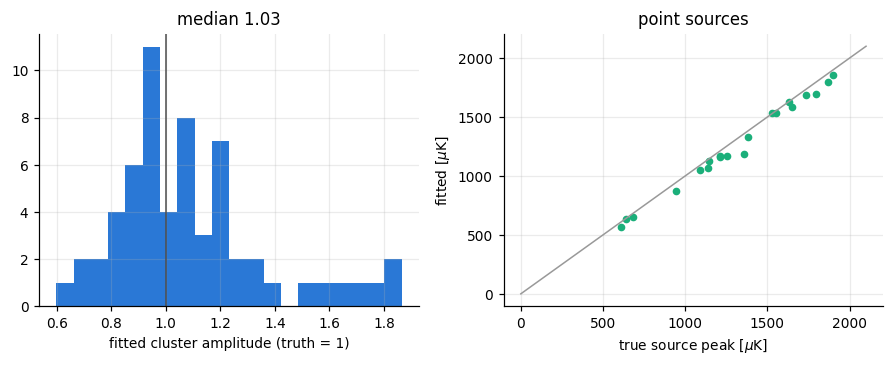

In [4]:
out = maps.build_object_model(
    shape,
    wcs,
    clusters=clusters,
    sources=sources,
    beam=BEAM_FWHM,
    freq_ghz=FREQ,
    amp_mode="fit",
    fit_map=observed,
    cl=cl,
    noise=NOISE,
    radius_arcmin=12.0,
    dec_band_deg=2.0,
)
cleaned = observed - out["model"]

# amplitude recovery: clusters are fit relative to the Arnaud prediction
# (truth = 1); sources against their catalog peaks
camps = np.array([r["amp"] for r in out["results"]["clusters"]])
sidx = np.array([r["idx"] for r in out["results"]["sources"]])
samps = np.array([r["amp"] for r in out["results"]["sources"]])
fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.4))
axes[0].hist(camps, bins=20, color=C[0])
axes[0].axvline(1.0, color="0.3", lw=1)
axes[0].set_xlabel("fitted cluster amplitude (truth = 1)")
axes[0].set_title(f"median {np.median(camps):.2f}")
axes[1].plot([0, 2100], [0, 2100], color="0.6", lw=1)
axes[1].scatter(sources["amps"][sidx], samps, s=16, color=C[1])
axes[1].set_xlabel("true source peak [$\\mu$K]")
axes[1].set_ylabel("fitted [$\\mu$K]")
axes[1].set_title("point sources")
fig.tight_layout()

central decrement removed: clusters 89.8%, sources 89.4%


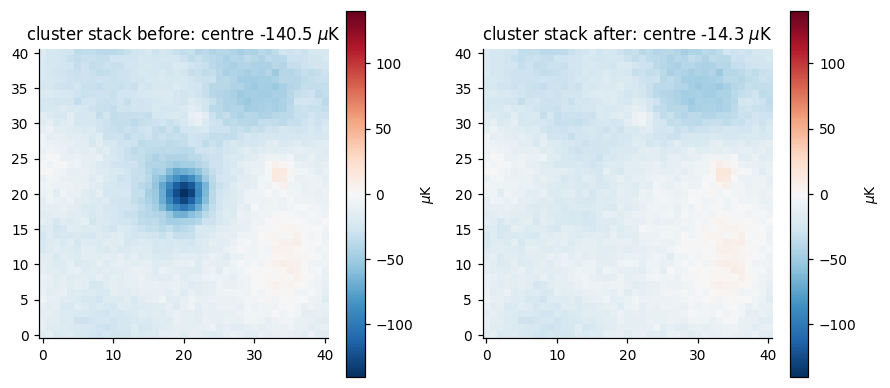

In [5]:
st = out["stacks"]["clusters"]
c1 = st["before"].shape[0] // 2
vmax = np.abs(st["before"]).max()
fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.6))
for ax, key in [(axes[0], "before"), (axes[1], "after")]:
    im = ax.imshow(st[key], origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(f"cluster stack {key}: centre {st[key][c1, c1]:+.1f} $\\mu$K")
    ax.grid(False)
    fig.colorbar(im, ax=ax, label="$\\mu$K")
fig.tight_layout()

red_c = 1.0 - st["after"][c1, c1] / st["before"][c1, c1]
ss = out["stacks"]["sources"]
red_s = 1.0 - ss["after"][c1, c1] / ss["before"][c1, c1]
print(f"central decrement removed: clusters {100 * red_c:.1f}%, sources {100 * red_s:.1f}%")

## Inpainting instead of modelling

When no source model is trusted, the positions can instead be *inpainted*
with `soma.maps.Inpainter`: each hole is replaced by the Gaussian-field value
conditioned on its surroundings.  Note the residual ring in the stack —
the cluster profile's wings extend beyond the hole radius, which is
exactly why fitting an extended model (above) beats hole-filling for
clusters, while inpainting shines for compact sources or untrusted
models.

soma.maps: filled 60 (slow 0, skipped 0, geometries 5)


Text(0.5, 1.0, 'cluster stack after inpainting: centre -24.4 $\\mu$K')

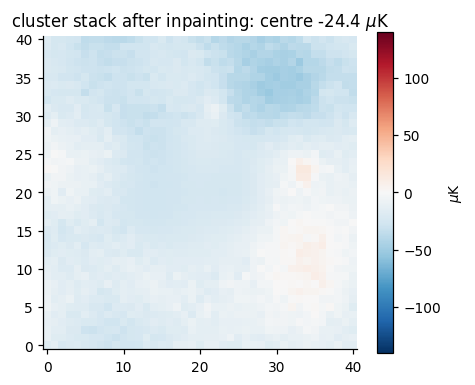

In [6]:
bl = maps._beam_fn(BEAM_FWHM)(ells)
inp = maps.Inpainter(
    cl,
    hole_arcmin=5.0,
    bl=bl,
    noise_uK_arcmin=NOISE,
    context_factor=2.4,
    dec_band_deg=3.0,
    mask_others=False,
)
inpainted, info = inp(observed, clusters["ras"], clusters["decs"], verbose=True)
stack_inp = maps.stack_thumbnails(inpainted, clusters["ras"], clusters["decs"], r_arcmin=10.0)

plt.figure(figsize=(4.6, 3.8))
plt.imshow(stack_inp, origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
plt.colorbar(label="$\\mu$K")
plt.grid(False)
plt.title(f"cluster stack after inpainting: centre {stack_inp[c1, c1]:+.1f} $\\mu$K")